In [25]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [26]:
panel_base = pd.read_parquet(os.path.join("../data/processed", "panel_base.parquet"))
panel_strict = pd.read_parquet(os.path.join("../data/processed", "panel_strict.parquet"))

In [27]:
panel_base.head()

,pos_holder,name_share_issuer,ISIN,net_short_pos,pos_date,month_end
0,artemis_investment_management,icap,GB0033872168,0.0052,2012-10-31,2012-10-31
1,pelham_long_short_master_fund,j_sainsbury,GB00B019KW72,0.0076,2012-10-31,2012-10-31
2,samlyn_capital,weir_group_the,GB0009465807,0.0062,2012-10-31,2012-10-31
3,stephen_james,ip_group,GB00B128J450,0.0099,2012-10-31,2012-10-31
4,ako_capital,pace,GB0006672785,0.0412,2012-11-20,2012-11-30


In [28]:
p = panel_base.copy()
p["tot"] = p.groupby(["ISIN", "month_end"]).net_short_pos.transform("sum")
p["s2"] = (p.net_short_pos/p.tot)**2

agg = p.groupby(["ISIN", "month_end"]).agg(
    agg_short=("net_short_pos", "sum"),
    n_holders=("pos_holder", "nunique"),
    hhi=("s2", "sum")
    ).reset_index()
agg["n_eff"] = 1/agg.hhi

In [29]:
cols = ["pos_holder", "ISIN", "month_end"]
pairs = p[cols].merge(p[cols], on=["pos_holder", "month_end"])
pairs = pairs[pairs.ISIN_x!=pairs.ISIN_y]
shared = pairs.groupby(["month_end", "ISIN_x", "ISIN_y"]).size().reset_index(name="n_shared")
ov = (shared[shared.n_shared>=2].groupby(["ISIN_x", "month_end"]).size()\
    .reset_index(name="overlap_deg").rename(columns={"ISIN_x":"ISIN"}))
agg = agg.merge(ov, on=["month_end", "ISIN"], how="left").fillna({"overlap_deg": 0})

In [30]:
m = p[p.month_end==p.month_end.max()]
B = nx.Graph()
B.add_nodes_from(m.pos_holder.unique(), bipartite=0)
B.add_nodes_from(m.ISIN.unique(), bipartite=1)
B.add_edges_from(m[["pos_holder", "ISIN"]].itertuples(index=False))

S = nx.bipartite.weighted_projected_graph(B, m.ISIN.unique())
S2 = nx.Graph([(u, v) for u, v, d in S.edges(data=True) if d["weight"]>=2])
comps = sorted(nx.connected_components(S2), key=len, reverse=True)
print(len(comps), [len(c) for c in comps[:5]])

1 [110]


In [31]:
m.columns

Index(['pos_holder', 'name_share_issuer', 'ISIN', 'net_short_pos', 'pos_date',
       'month_end', 'tot', 's2'],
      dtype='str')

In [32]:
giant = max(nx.connected_components(S2), key=len)
comms = sorted(nx.community.louvain_communities(S2, weight="weight", seed=42),
               key=len, reverse=True)

In [33]:
n_communities        = len(comms)
largest_comm_size    = len(comms[0])
largest_comm_density = nx.density(S2.subgraph(comms[0]))
print(n_communities); print(largest_comm_size); print(largest_comm_density)

5
34
0.1622103386809269


In [34]:
rows = [{"isin": s, "community_id": i, "community_size": len(c),
         "community_density": nx.density(S2.subgraph(c)), "in_giant": s in giant}
        for i, c in enumerate(comms) for s in c]
cm = pd.DataFrame(rows)

unlinked = set(m.ISIN) - set(S2.nodes)
cm = pd.concat([cm, pd.DataFrame({"isin": list(unlinked), "community_id": -1,
                "community_size": 1, "community_density": np.nan, "in_giant": False})])

In [35]:
assert sum(len(c) for c in comms) == S2.number_of_nodes()      # every linked stock in exactly one community
assert set().union(*comms) == set(S2.nodes)
assert len(cm) == m.ISIN.nunique()                              # every shorted stock appears once
assert cm.in_giant.sum() == len(giant)
assert all(c <= giant or not (c & giant) for c in comms)        # no community straddles components

In [36]:
for s in range(10):
    c = sorted(nx.community.louvain_communities(S2, weight="weight", seed=s), key=len, reverse=True)
    print(s, len(c), len(c[0]), round(nx.density(S2.subgraph(c[0])), 2))

0 6 32 0.2
1 6 28 0.22
2 7 24 0.22
3 6 32 0.32
4 6 29 0.33
5 6 28 0.33
6 6 26 0.23
7 6 35 0.31
8 6 30 0.21
9 5 31 0.2


In [37]:
m.head()

,pos_holder,name_share_issuer,ISIN,net_short_pos,pos_date,month_end,tot,s2
57451,acadian_asset_management,essentra,GB00B0744359,0.0059,2026-06-29,2026-06-30,0.0203,0.084472
57452,acadian_asset_management,crest_nicholson_holdings,GB00B8VZXT93,0.0118,2026-06-30,2026-06-30,0.0817,0.020860
57453,acadian_asset_management,genuit_group,GB00BKRC5K31,0.0061,2026-06-30,2026-06-30,0.0581,0.011023
57454,acadian_asset_management,capita,GB00BPCT7534,0.0093,2026-05-18,2026-06-30,0.0705,0.017402
57455,acadian_asset_management,pinewood_technologies_group,GB00BSB7BS06,0.0073,2026-04-02,2026-06-30,0.0714,0.010453


In [45]:
comps[0]

{'BMG4593F1389',
 'GB0000811801',
 'GB0000904986',
 'GB0001638955',
 'GB0001859296',
 'GB0002374006',
 'GB0002869419',
 'GB0003452173',
 'GB0004161021',
 'GB0004478896',
 'GB0004536594',
 'GB0004915632',
 'GB0005576813',
 'GB0005603997',
 'GB0006027295',
 'GB0006215205',
 'GB0006731235',
 'GB0006776081',
 'GB0006825383',
 'GB0006870611',
 'GB0006928617',
 'GB0007668071',
 'GB0008782301',
 'GB0008794710',
 'GB0009039941',
 'GB0009223206',
 'GB0009292243',
 'GB0009465807',
 'GB0030232317',
 'GB0030913577',
 'GB0031743007',
 'GB0032398678',
 'GB0033147751',
 'GB0033195214',
 'GB0033986497',
 'GB00B012BV22',
 'GB00B019KW72',
 'GB00B01QGK86',
 'GB00B04V1276',
 'GB00B0744359',
 'GB00B0CY5V57',
 'GB00B0KM9T71',
 'GB00B0LCW083',
 'GB00B0WMWD03',
 'GB00B0YD2B94',
 'GB00B1KJJ408',
 'GB00B1V9NW54',
 'GB00B1VQ6H25',
 'GB00B1ZBKY84',
 'GB00B2863827',
 'GB00B2PDGW16',
 'GB00B3MBS747',
 'GB00B45C9X44',
 'GB00B61TVQ02',
 'GB00B63QSB39',
 'GB00B7KR2P84',
 'GB00B8VZXT93',
 'GB00BD3VFW73',
 'GB00BF345X11

In [38]:
big = comps[0]
names = panel_base.drop_duplicates("ISIN").set_index("ISIN")["name_share_issuer"]
stocks = (m[m.ISIN.isin(big)].groupby("ISIN")
            .agg(agg_short=("net_short_pos", "sum"),
            n_holders=("pos_holder", "nunique"))
            .assign(name=lambda d: d.index.map(names))
            .sort_values("agg_short", ascending=False)
        )
print(len(stocks)); print(stocks.head(10))

110
              agg_short  n_holders                         name
ISIN                                                           
GB0001859296     0.1429         14                 vistry_group
GB00BYXJC278     0.1305         13                      ibstock
GB00B63QSB39     0.0970         10                       greggs
GB00B2PDGW16     0.0961         11                     wh_smith
GB00B3MBS747     0.0847         12                  ocado_group
JE00BN574F90     0.0840          8            wizz_air_holdings
GB00B8VZXT93     0.0817          8     crest_nicholson_holdings
GB00BYN59130     0.0729          9         domino_s_pizza_group
GB00BSB7BS06     0.0714          9  pinewood_technologies_group
GB00BPCT7534     0.0705          9                       capita


In [39]:
mc = m[m.ISIN.isin(big)]
funds = (
    mc.groupby("pos_holder")
    .agg(n_stocks=("ISIN", "nunique"), total_pct=("net_short_pos", "sum"))
    .sort_values("n_stocks", ascending=False)
)
print(len(funds)); print(funds.head(10))

74
                                         n_stocks  total_pct
pos_holder                                                  
glg_partners                                   46     0.4071
citadel_advisors                               35     0.3395
jpmorgan_asset_management                      24     0.3007
aqr_capital_management                         21     0.1332
marshall_wace                                  20     0.1613
d_e_shaw_co                                    19     0.1553
two_sigma_investments                          19     0.1605
actusraypartners                               19     0.1385
connor_clark_lunn_investment_management        15     0.1146
kintbury_capital                               14     0.2342


In [40]:
grid = mc.pivot_table(index="pos_holder", columns="ISIN", values="net_short_pos", fill_value=0)
grid = grid.loc[funds.index, stocks.index]
print((grid>0).astype(int))

ISIN                         GB0001859296  GB00BYXJC278  GB00B63QSB39  \
pos_holder                                                              
glg_partners                            1             0             1   
citadel_advisors                        1             1             1   
jpmorgan_asset_management               0             1             1   
aqr_capital_management                  1             1             0   
marshall_wace                           0             0             0   
...                                   ...           ...           ...   
spark_investment_management             0             0             0   
surgocap_partners                       0             0             0   
shadowfall_capital_research             0             0             0   
vor_capital                             0             0             0   
white_creek_capital                     0             0             0   

ISIN                         GB00B2PDGW16  GB00B3M

In [41]:
sub = S2.subgraph(big)
print(f"density: {nx.density(sub)}")
w = [S[u][v]["weight"] for u, v in sub.edges()]
print(np.mean(w), np.median(w), max(w))

density: 0.11976647206005005
2.2827298050139277 2.0 7


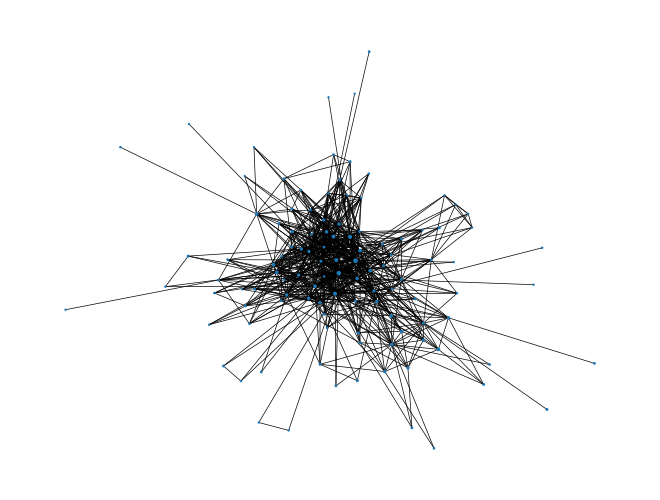

In [42]:
nx.draw_spring(sub, with_labels=False, node_size=[stocks.loc[n, "agg_short"] * 40 for n in sub], width=0.5)
plt.show()

In [43]:
agg.sort_values("overlap_deg", ascending=False).head()

,ISIN,month_end,agg_short,n_holders,hhi,n_eff,overlap_deg
13869,GB00B2PDGW16,2026-03-31,0.0886,10,0.115211,8.679743,64.0
13871,GB00B2PDGW16,2026-05-31,0.1227,13,0.092109,10.856684,62.0
13872,GB00B2PDGW16,2026-06-30,0.0961,11,0.104772,9.544549,60.0
24775,GB00BYXJC278,2026-05-31,0.1544,15,0.082700,12.091868,55.0
25714,IE0003864109,2018-05-31,0.1257,13,0.103281,9.682325,54.0


agg_short  agg_short   n_holders       n_eff  overlap_deg
count          165.0  164.000000  164.000000   164.000000
mean             1.0    0.831773    0.805898     0.616700
std              0.0    0.046912    0.048081     0.113688
min              1.0    0.674990    0.653928     0.235212
25%              1.0    0.802628    0.777676     0.558817
50%              1.0    0.838410    0.811721     0.624706
75%              1.0    0.864545    0.840788     0.694652
max              1.0    0.929391    0.902446     0.852322


<Axes: xlabel='month_end'>

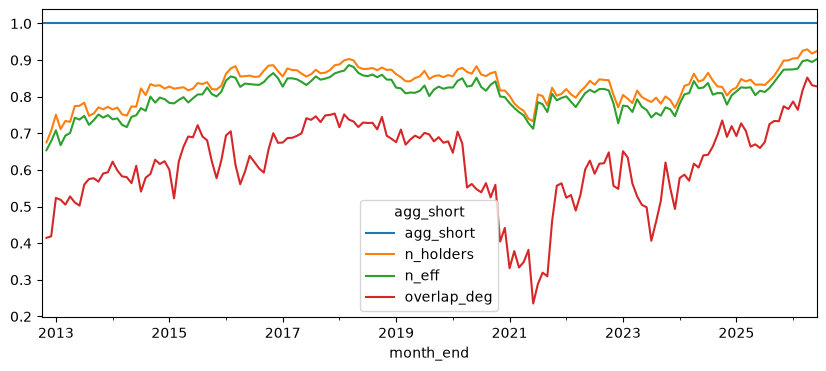

In [44]:
rho = agg.groupby("month_end").apply(
    lambda g: g[["agg_short", "n_holders", "n_eff", "overlap_deg"]].corr("spearman").loc["agg_short"])
print(rho.describe())
rho.plot(figsize=(10, 4))

In [46]:
df = pd.read_parquet(os.path.join("../data/processed", "network_monthly_base.parquet"))
df.head()

,month_end,n_stocks,n_funds,n_positions,n_stocks_linked,giant_size,giant_share,giant_density,median_shared,max_shared,n_communities,largest_comm_size,largest_comm_density
0,2012-11-30,138,89,240,22,8,0.057971,0.464286,2.0,2,5,8,0.464286
1,2012-12-31,138,86,235,20,5,0.036232,0.500000,2.0,2,5,5,0.500000
2,2013-01-31,133,89,239,23,14,0.105263,0.153846,2.0,2,5,8,0.285714
3,2013-02-28,128,92,236,23,10,0.078125,0.222222,2.0,2,7,5,0.600000
4,2013-03-31,135,91,244,21,11,0.081481,0.218182,2.0,2,5,6,0.533333
